### Import packages

In [7]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score
import plotly.express as px 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN

### Load the dataset

In [8]:
global_mobile_df = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\processed_data\Mobile_Reviews_Sentiment_cleaned_data.csv")

print(global_mobile_df.info())



<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    50000 non-null  float64
 1   price_usd              50000 non-null  float64
 2   rating                 50000 non-null  float64
 3   verified_purchase      50000 non-null  float64
 4   battery_life_rating    50000 non-null  float64
 5   camera_rating          50000 non-null  float64
 6   performance_rating     50000 non-null  float64
 7   design_rating          50000 non-null  float64
 8   display_rating         50000 non-null  float64
 9   helpful_votes          50000 non-null  float64
 10  price_local_value      50000 non-null  float64
 11  day                    50000 non-null  float64
 12  month                  50000 non-null  float64
 13  year                   50000 non-null  float64
 14  sentiments             50000 non-null  float64
 15  brand_Apple  

Normalize the data for cosine similarity

In [9]:
global_mobile_df_normalized = normalize(global_mobile_df)

the two methods to find the best k

1. Elbow method → plot inertia vs K → look for the bend
2. Silhouette score → measure cluster quality → higher is better

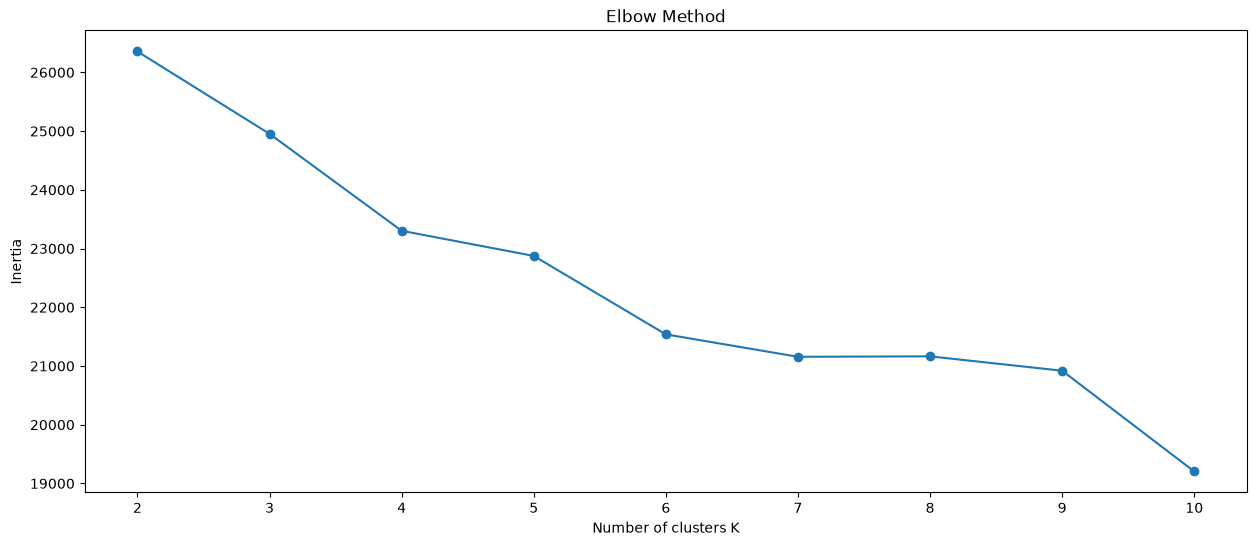

In [10]:
inertia = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(global_mobile_df_normalized)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(15, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.show()